In [ ]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import Optional, List, Dict, Any, Literal
from datetime import datetime

class UserQueryState(BaseModel):
    
    
    # Input processing
    user_query: str
    query_type: Optional[Literal["calendar", "sheets"]] = None
    confidence_score: float = 0.0
    
    # Calendar flow states
    meeting_request_parsed: bool = False
    meeting_details: Optional[Dict[str, Any]] = None
    input_valid: bool = False
    calendar_availability_checked: bool = False
    available_slot_found: bool = False
    suggested_times: List[Dict[str, Any]] = Field(default_factory=list)
    meeting_invite_created: bool = False
    
    # Sheets flow states  
    sheets_operation: Optional[Literal["create", "update", "read", "delete"]] = None
    sheets_data: Optional[Dict[str, Any]] = None
    sheets_validation_passed: bool = False
    sheets_operation_completed: bool = False
    target_sheet_id: Optional[str] = None
    
    # Notification and completion
    notification_created: bool = False
    workflow_completed: bool = False
    
    # Error handling
    has_errors: bool = False
    error_messages: List[str] = Field(default_factory=list)
    
    # Audit trail
    workflow_id: str = ""
    started_at: Optional[datetime] = None
    completed_at: Optional[datetime] = None


In [8]:

async def handle_user_input_message(state: UserQueryState) -> UserQueryState:

    
    # Initialize workflow metadata
    state.workflow_id = f"workflow_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    state.started_at = datetime.now()
    
    # Analyze query type using keywords and AI
    query_lower = state.user_query.lower()
    
    # Calendar/Meeting keywords
    calendar_keywords = ['meeting', 'schedule', 'calendar', 'appointment', 'call', 'sync', 'discuss']
    sheets_keywords = ['sheet', 'spreadsheet', 'data', 'update', 'create', 'table', 'row', 'column']
    
    calendar_score = sum(1 for keyword in calendar_keywords if keyword in query_lower)
    sheets_score = sum(1 for keyword in sheets_keywords if keyword in query_lower)
    
    if calendar_score > sheets_score:
        state.query_type = "calendar"
        state.confidence_score = min(1.0, calendar_score / len(calendar_keywords) * 2)
    else:
        state.query_type = "sheets" 
        state.confidence_score = min(1.0, sheets_score / len(sheets_keywords) * 2)
    
    print(f"Query classified as: {state.query_type} (confidence: {state.confidence_score:.2f})")
    return state


async def calendar_invite_handler(state: UserQueryState) -> UserQueryState:
    
    print("Entering calendar invite workflow")
    return state

async def parse_meeting_request(state: UserQueryState) -> UserQueryState:
    """Parse meeting details from user query"""
    print("Parsing meeting request details")
    
    try:
        
        meeting_details = {
            "title": "Team Meeting",  
            "participants": [],
            "duration": 30,  
            "preferred_time": None,
            "location": None,
            "description": state.user_query
        }
        
        
        if "with" in state.user_query.lower():
           
            meeting_details["participants"] = ["user1", "user2"]  
        
        if any(time_word in state.user_query.lower() for time_word in ["today", "tomorrow", "monday", "tuesday"]):
            meeting_details["preferred_time"] = "extracted_time"
        
        state.meeting_details = meeting_details
        state.meeting_request_parsed = True
        
        print(f"Meeting request parsed: {meeting_details}")
        
    except Exception as e:
        state.has_errors = True
        state.error_messages.append(f"Meeting parsing error: {str(e)}")
        print(f"Error parsing meeting: {str(e)}")
    
    return state

async def validate_input(state: UserQueryState) -> UserQueryState:

    
    if not state.meeting_details:
        state.input_valid = False
        state.error_messages.append("No meeting details found")
        return state
    
    
    validation_errors = []
    
    if not state.meeting_details.get("title"):
        validation_errors.append("Meeting title required")
    
    if state.meeting_details.get("duration", 0) <= 0:
        validation_errors.append("Valid duration required")
    
    if validation_errors:
        state.input_valid = False
        state.error_messages.extend(validation_errors)
        print(f"Validation failed: {validation_errors}")
    else:
        state.input_valid = True
        print("Input validation passed")
    
    return state

async def check_calendar_availability(state: UserQueryState) -> UserQueryState:
    """Check calendar availability for meeting"""
    print("Checking calendar availability")
    
    try:
        
        preferred_time = state.meeting_details.get("preferred_time")
        

        if preferred_time:

            state.available_slot_found = True  
        else:
           
            state.available_slot_found = False
        
        state.calendar_availability_checked = True
        print(f"Availability check complete. Slot found: {state.available_slot_found}")
        
    except Exception as e:
        state.has_errors = True
        state.error_messages.append(f"Calendar check error: {str(e)}")
        print(f"Calendar availability check failed: {str(e)}")
    
    return state

async def find_available_slot(state: UserQueryState) -> UserQueryState:
    """Find and book available time slot"""
    print("Finding available time slot")
    
    try:
       
        available_slot = {
            "start_time": "2025-09-10T14:00:00",
            "end_time": "2025-09-10T14:30:00",
            "timezone": "Asia/Kolkata"
        }
        
       
        state.meeting_details["confirmed_time"] = available_slot
        
        print(f"Available slot found: {available_slot}")
        
    except Exception as e:
        state.has_errors = True
        state.error_messages.append(f"Slot finding error: {str(e)}")
    
    return state

async def suggest_alternate_time(state: UserQueryState) -> UserQueryState:
    """Suggest alternate meeting times"""
    print("Suggesting alternate meeting times")
    
    try:
        
        alternate_times = [
            {
                "start_time": "2025-09-10T15:00:00",
                "end_time": "2025-09-10T15:30:00",
                "reason": "Next available slot"
            },
            {
                "start_time": "2025-09-11T10:00:00", 
                "end_time": "2025-09-11T10:30:00",
                "reason": "Tomorrow morning"
            },
            {
                "start_time": "2025-09-11T14:00:00",
                "end_time": "2025-09-11T14:30:00", 
                "reason": "Tomorrow afternoon"
            }
        ]
        
        state.suggested_times = alternate_times
        print(f"Suggested {len(alternate_times)} alternate times")
        
    except Exception as e:
        state.has_errors = True
        state.error_messages.append(f"Time suggestion error: {str(e)}")
    
    return state

async def create_meeting_invite(state: UserQueryState) -> UserQueryState:
    """Create the actual meeting invite"""
    print("Creating meeting invite")
    
    try:
        
        meeting_data = {
            "summary": state.meeting_details["title"],
            "description": state.meeting_details.get("description", ""),
            "start": state.meeting_details.get("confirmed_time", {}).get("start_time"),
            "end": state.meeting_details.get("confirmed_time", {}).get("end_time"),
            "attendees": state.meeting_details.get("participants", [])
        }
        
        
        event_id = f"event_{state.workflow_id}"
        state.meeting_details["event_id"] = event_id
        state.meeting_invite_created = True
        
        print(f"Meeting invite created with ID: {event_id}")
        
    except Exception as e:
        state.has_errors = True
        state.error_messages.append(f"Invite creation error: {str(e)}")
    
    return state



async def sheets_handler(state: UserQueryState) -> UserQueryState:
    """Handle Google Sheets operations workflow"""
    print("Entering Google Sheets workflow")
    
    try:
        
        query_lower = state.user_query.lower()
        
        if any(word in query_lower for word in ["create", "new", "make"]):
            state.sheets_operation = "create"
        elif any(word in query_lower for word in ["update", "modify", "change", "edit"]):
            state.sheets_operation = "update" 
        elif any(word in query_lower for word in ["read", "get", "show", "display"]):
            state.sheets_operation = "read"
        elif any(word in query_lower for word in ["delete", "remove", "clear"]):
            state.sheets_operation = "delete"
        else:
            state.sheets_operation = "read"  
        
        print(f"Sheets operation identified: {state.sheets_operation}")
        
    except Exception as e:
        state.has_errors = True
        state.error_messages.append(f"Sheets analysis error: {str(e)}")
    
    return state

async def parse_sheets_request(state: UserQueryState) -> UserQueryState:
    """Parse sheets operation details"""
    print("🔍 Parsing sheets request details")
    
    try:
        sheets_data = {
            "operation": state.sheets_operation,
            "sheet_name": "Default Sheet",
            "data": [],
            "range": "A1:Z100",
            "headers": []
        }
        
        
        if state.sheets_operation == "create":
            sheets_data.update({
                "sheet_name": "New Meeting Log",
                "headers": ["Date", "Meeting Title", "Participants", "Duration", "Status"],
                "initial_data": []
            })
        elif state.sheets_operation == "update":
            sheets_data.update({
                "target_range": "A2:E2",
                "new_values": ["2025-09-09", "Team Sync", "John, Jane", "30 min", "Scheduled"]
            })
        elif state.sheets_operation == "read":
            sheets_data.update({
                "read_range": "A1:Z100"
            })
        elif state.sheets_operation == "delete":
            sheets_data.update({
                "delete_range": "A2:E2"
            })
        
        state.sheets_data = sheets_data
        print(f"Sheets request parsed: {sheets_data}")
        
    except Exception as e:
        state.has_errors = True
        state.error_messages.append(f"Sheets parsing error: {str(e)}")
    
    return state

async def validate_sheets_data(state: UserQueryState) -> UserQueryState:
    """Validate sheets operation data"""
    print("Validating sheets data")
    
    try:
        if not state.sheets_data:
            state.sheets_validation_passed = False
            state.error_messages.append("No sheets data to validate")
            return state
        
        validation_errors = []
        
        # Validate based on operation type
        if state.sheets_operation == "create":
            if not state.sheets_data.get("sheet_name"):
                validation_errors.append("Sheet name required for creation")
        elif state.sheets_operation == "update":
            if not state.sheets_data.get("target_range"):
                validation_errors.append("Target range required for update")
            if not state.sheets_data.get("new_values"):
                validation_errors.append("New values required for update")
        
        if validation_errors:
            state.sheets_validation_passed = False
            state.error_messages.extend(validation_errors)
            print(f"Sheets validation failed: {validation_errors}")
        else:
            state.sheets_validation_passed = True
            print("Sheets validation passed")
    
    except Exception as e:
        state.has_errors = True
        state.error_messages.append(f"Sheets validation error: {str(e)}")
    
    return state

async def execute_sheets_operation(state: UserQueryState) -> UserQueryState:
    """Execute the sheets operation"""
    print(f"Executing sheets operation: {state.sheets_operation}")
    
    try:
        if state.sheets_operation == "create":
            
            print("Creating new sheet/data")
            result = {
                "sheet_id": "new_sheet_123",
                "operation": "create",
                "rows_created": 1,
                "status": "success"
            }
        elif state.sheets_operation == "update":
            
            print("Updating sheet data") 
            result = {
                "operation": "update",
                "cells_updated": len(state.sheets_data.get("new_values", [])),
                "status": "success"
            }
        elif state.sheets_operation == "read":
            
            print("Reading sheet data")
            result = {
                "operation": "read", 
                "data": [["Date", "Title", "Status"], ["2025-09-09", "Team Meeting", "Scheduled"]],
                "rows_read": 2,
                "status": "success"
            }
        elif state.sheets_operation == "delete":
            
            print("Deleting sheet data")
            result = {
                "operation": "delete",
                "rows_deleted": 1,
                "status": "success"
            }
        
        state.sheets_data["result"] = result
        state.sheets_operation_completed = True
        print(f"Sheets operation completed: {result}")
        
    except Exception as e:
        state.has_errors = True
        state.error_messages.append(f"Sheets operation error: {str(e)}")
    
    return state


async def create_notification_popup(state: UserQueryState) -> UserQueryState:
    """Create notification popup for user"""
    print("Creating notification popup")
    
    try:
        if state.query_type == "calendar":
            if state.meeting_invite_created:
                notification = {
                    "type": "success",
                    "title": "Meeting Scheduled Successfully!",
                    "message": f"Your meeting '{state.meeting_details['title']}' has been scheduled.",
                    "actions": ["View Calendar", "Send Reminder"]
                }
            elif state.suggested_times:
                notification = {
                    "type": "info", 
                    "title": "Meeting Time Suggestions",
                    "message": f"Found {len(state.suggested_times)} available time slots.",
                    "actions": ["View Suggestions", "Pick Different Time"]
                }
            else:
                notification = {
                    "type": "error",
                    "title": "Meeting Scheduling Failed", 
                    "message": "Unable to schedule meeting. Please try again.",
                    "actions": ["Retry", "Contact Support"]
                }
        else:  
            if state.sheets_operation_completed:
                operation_msg = {
                    "create": "Data created successfully",
                    "update": "Data updated successfully", 
                    "read": "Data retrieved successfully",
                    "delete": "Data deleted successfully"
                }
                notification = {
                    "type": "success",
                    "title": "Sheets Operation Complete",
                    "message": operation_msg.get(state.sheets_operation, "Operation completed"),
                    "actions": ["View Sheet", "Perform Another Operation"]
                }
            else:
                notification = {
                    "type": "error",
                    "title": "Sheets Operation Failed",
                    "message": "Unable to complete sheets operation.",
                    "actions": ["Retry", "Check Permissions"]
                }
        
        state.notification_created = True
        print(f"Notification created: {notification['title']}")
        
    except Exception as e:
        state.has_errors = True
        state.error_messages.append(f"Notification error: {str(e)}")
    
    return state

async def finalize_workflow(state: UserQueryState) -> UserQueryState:
    """Finalize workflow and cleanup"""
    print("Finalizing workflow")
    
    state.workflow_completed = True
    state.completed_at = datetime.now()
    
    duration = (state.completed_at - state.started_at).total_seconds() if state.started_at else 0
    print(f"Workflow {state.workflow_id} completed in {duration:.2f} seconds")
    
    return state


In [3]:
def decide_query_type(state: UserQueryState) -> str:
    """Route based on query type classification"""
    if state.query_type == "calendar":
        return "calendar_invite"
    else:
        return "sheets"

def decide_input_validation(state: UserQueryState) -> str:
    """Route based on input validation result"""
    if state.input_valid:
        return "check_calendar_availability"
    else:
        return "create_notification"

def decide_availability_action(state: UserQueryState) -> str:
    """Route based on calendar availability"""
    if state.available_slot_found:
        return "find_available_slot"
    else:
        return "suggest_alternate_time"

def decide_sheets_validation(state: UserQueryState) -> str:
    """Route based on sheets validation"""
    if state.sheets_validation_passed:
        return "execute_sheets_operation"
    else:
        return "create_notification"


In [9]:
def create_user_query_workflow():
    """Create the complete LangGraph workflow"""
    
    # Initialize the state graph
    workflow = StateGraph(UserQueryState)
    
    # Add all nodes
    workflow.add_node("handle_input", handle_user_input_message)
    workflow.add_node("calendar_invite", calendar_invite_handler) 
    workflow.add_node("sheets", sheets_handler)
    workflow.add_node("parse_meeting_request", parse_meeting_request)
    workflow.add_node("validate_input", validate_input)
    workflow.add_node("check_calendar_availability", check_calendar_availability)
    workflow.add_node("find_available_slot", find_available_slot)
    workflow.add_node("create_meeting_invite", create_meeting_invite)
    workflow.add_node("suggest_alternate_time", suggest_alternate_time)
    workflow.add_node("parse_sheets_request", parse_sheets_request)
    workflow.add_node("validate_sheets_data", validate_sheets_data)
    workflow.add_node("execute_sheets_operation", execute_sheets_operation)
    workflow.add_node("create_notification", create_notification_popup)
    workflow.add_node("finalize", finalize_workflow)
    
    
    workflow.add_edge(START, "handle_input")
    
    # Initial routing
    workflow.add_conditional_edges(
        "handle_input",
        decide_query_type,
        {
            "calendar_invite": "calendar_invite",
            "sheets": "sheets"
        }
    )
    
    # Calendar flow
    workflow.add_edge("calendar_invite", "parse_meeting_request")
    workflow.add_edge("parse_meeting_request", "validate_input")
    workflow.add_conditional_edges(
        "validate_input",
        decide_input_validation,
        {
            "check_calendar_availability": "check_calendar_availability",
            "create_notification": "create_notification"
        }
    )
    
    workflow.add_conditional_edges(
        "check_calendar_availability",
        decide_availability_action,
        {
            "find_available_slot": "find_available_slot",
            "suggest_alternate_time": "suggest_alternate_time"
        }
    )
    
    workflow.add_edge("find_available_slot", "create_meeting_invite")
    workflow.add_edge("suggest_alternate_time", "create_notification")
    workflow.add_edge("create_meeting_invite", "create_notification")
    
    # Sheets flow
    workflow.add_edge("sheets", "parse_sheets_request")
    workflow.add_edge("parse_sheets_request", "validate_sheets_data")
    workflow.add_conditional_edges(
        "validate_sheets_data",
        decide_sheets_validation,
        {
            "execute_sheets_operation": "execute_sheets_operation",
            "create_notification": "create_notification"
        }
    )
    workflow.add_edge("execute_sheets_operation", "create_notification")
    
    # Final convergence
    workflow.add_edge("create_notification", "finalize")
    workflow.add_edge("finalize", END)
    
    # Compile the graph
    compiled_graph = workflow.compile()
    
    return compiled_graph



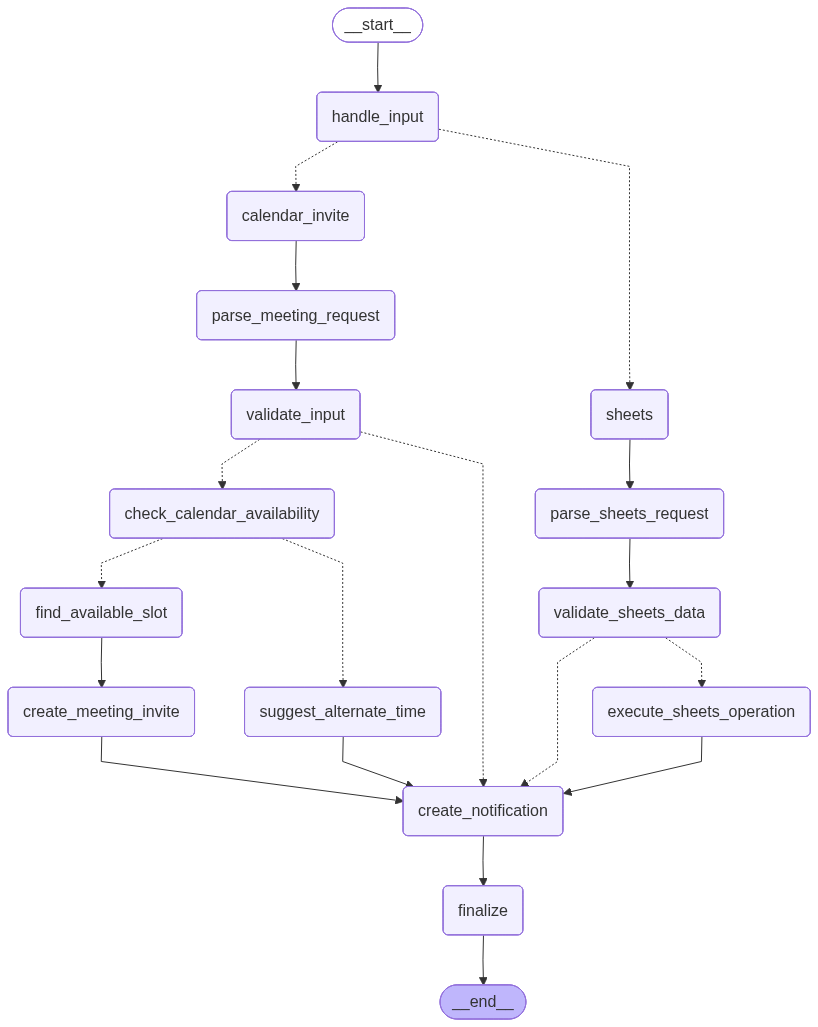

In [7]:
compiled_workflow = create_user_query_workflow()

from IPython.display import Image, display
display(Image(compiled_workflow.get_graph().draw_mermaid_png()))